In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
import cv2
from scipy import ndimage
import albumentations as A
import random
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load a sample dataset - we'll use both a tabular dataset and an image dataset
# For tabular data, let's use the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Basic Exploration
print(f"Dataset shape: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (891, 12)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna('Unknown', inplace=True)

# ----- FEATURE ENGINEERING FOR TABULAR DATA -----

In [6]:
# 1. Extract title from name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [7]:
# 2. Create family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

In [8]:
# 3. Create is_alone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [9]:
# 4. Create fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

In [10]:
# 5. Bin age into categories
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 65, 100], labels=['Child', 'Teenager', 'Adult', 'Elderly'])

In [11]:
# 6. Bin fare into categories
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])


In [12]:
# 7. Create deck from cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace(['T', 'A', 'G'], 'Other')
df['Deck'] = df['Deck'].replace('Unknown', 'U')


In [13]:
# 8. Interaction features
df['Family_Survival'] = df['FamilySize'] * df['Survived']


In [14]:
# 9. Categorical encodings
# One-hot encoding for categorical features
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'Deck']
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

In [15]:
# Combine with numerical features
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
X = pd.concat([df[numerical_features], df_encoded], axis=1)
y = df['Survived']

In [16]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Feature selection using SelectKBest
selector = SelectKBest(f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

In [18]:
# Display top features
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})
top_features = feature_scores.sort_values('Score', ascending=False).head(15)
print("\nTop 15 features:")
print(top_features)


Top 15 features:
              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
26             Deck_U   99.253142
3                Fare   63.030764
20  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
22             Deck_D   20.663186
10         Embarked_S   20.374460
23             Deck_E   19.179221
21             Deck_C   11.841661
18     FareBin_Medium    8.208162


In [19]:
# Train a model with the engineered features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.25, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# Evaluate the model
y_pred = model.predict(X_test)
print("\nModel accuracy with engineered features:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Model accuracy with engineered features: 0.8116591928251121

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       134
           1       0.76      0.78      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



# ----- ADVANCED FEATURE ENGINEERING -----

In [21]:
# 1. Polynomial features (example with a simple subset)
from sklearn.preprocessing import PolynomialFeatures

In [22]:
# Just using Age and Fare for demonstration
poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_data = poly_features.fit_transform(df[['Age', 'Fare']].fillna(0))

In [23]:
# Display polynomial feature names
feature_names = poly_features.get_feature_names_out(['Age', 'Fare'])
print("\nPolynomial features generated:")
print(feature_names)


Polynomial features generated:
['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


In [24]:
# 2. PCA for dimensionality reduction
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

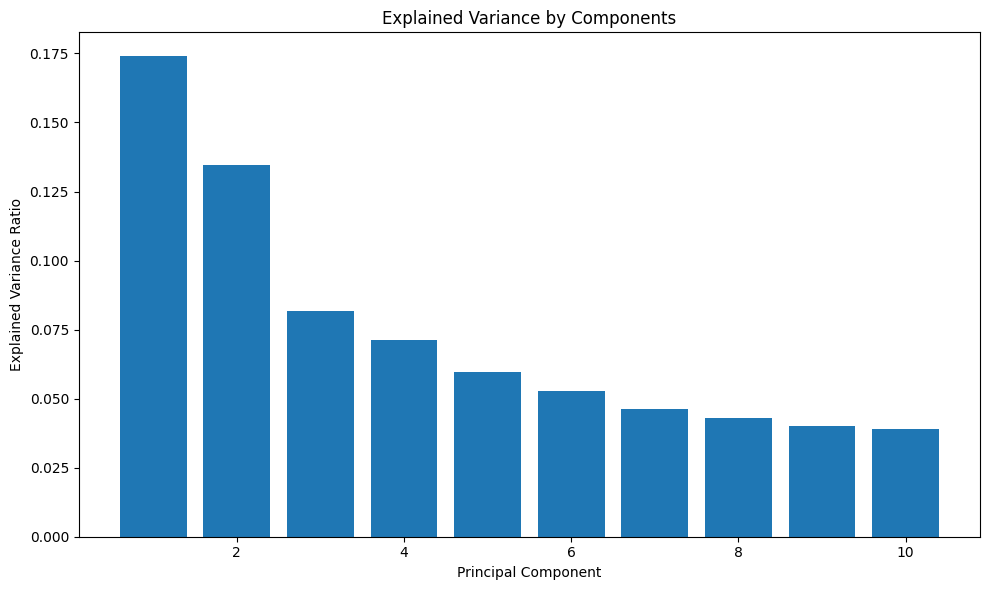

In [25]:
# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Components')
plt.tight_layout()
plt.show()

In [26]:
# Print cumulative explained variance
print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))


Cumulative explained variance:
[0.17394189 0.30865766 0.39044823 0.46166279 0.52117907 0.57399528
 0.62017507 0.66317021 0.70334202 0.74223912]


# ----- DATA AUGMENTATION FOR IMAGES -----

In [27]:
# Load MNIST dataset for image augmentation examples
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [28]:
# Normalize the data
X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

In [29]:
# Expand dimensions for Keras (add channel dimension)
X_train_img = X_train_img.reshape(-1, 28, 28, 1)
X_test_img = X_test_img.reshape(-1, 28, 28, 1)

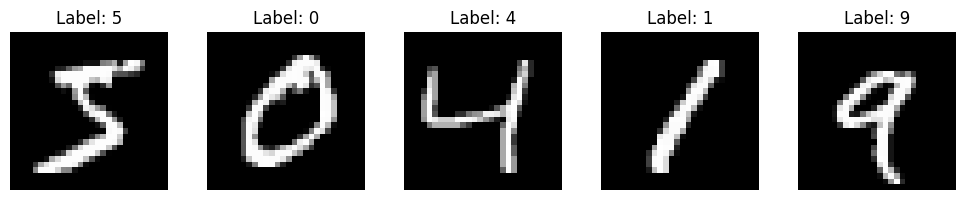

In [30]:
# Display some original images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_img[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {y_train_img[i]}")
plt.tight_layout()
plt.show()


In [31]:
# ----- 1. BASIC IMAGE AUGMENTATION WITH KERAS -----

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    # brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

In [34]:
# Visualize augmented images
augmented_images = []

for x_batch in datagen.flow(X_train_img[:5], batch_size=1, shuffle=False):
    augmented_images.append(x_batch[0])
    if len(augmented_images) >= 15:  # Generate 3 augmented versions of each of the 5 images
        break

augmented_images = np.array(augmented_images)

In [35]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape for ImageDataGenerator: (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)

# Create augmentation generator
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Visualize augmented images
augmented_images = []

for x_batch in datagen.flow(x_train[:5], batch_size=1, shuffle=False):
    augmented_images.append(x_batch[0])
    if len(augmented_images) >= 15:
        break

augmented_images = np.array(augmented_images)

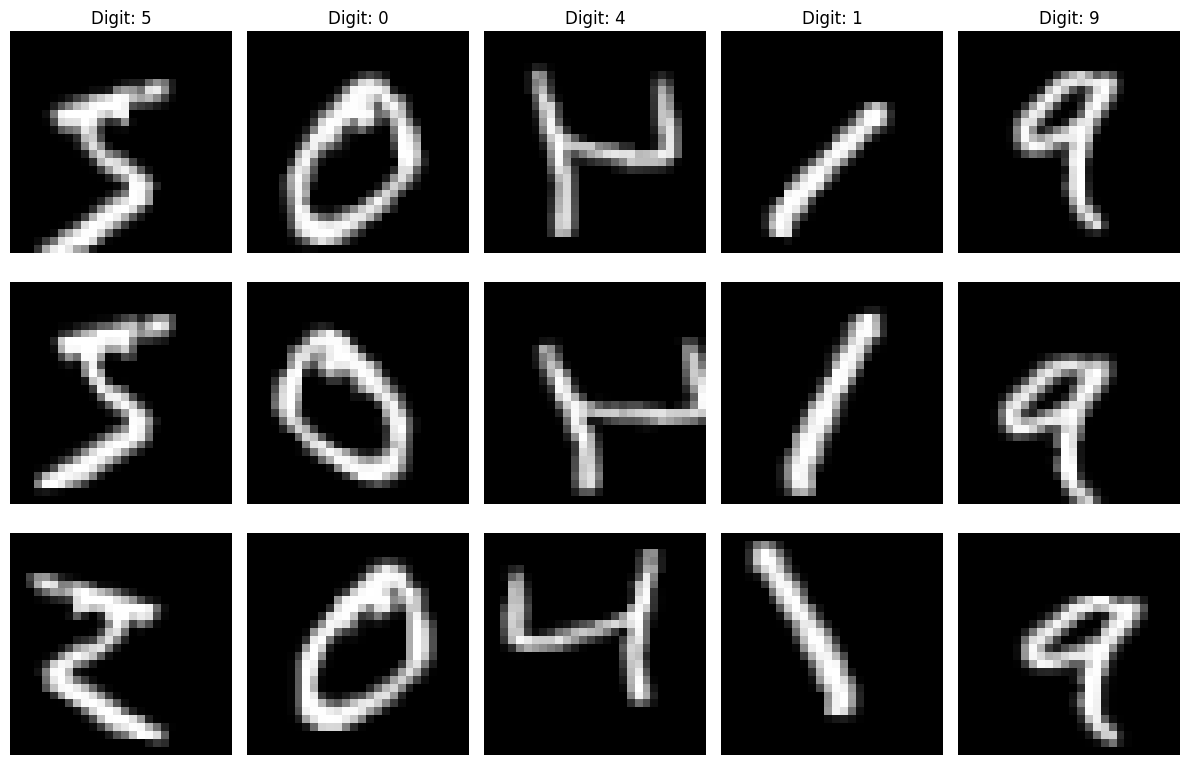

In [36]:
import matplotlib.pyplot as plt

# Display augmented images
plt.figure(figsize=(12, 8))

for i, img in enumerate(augmented_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')

    if i < 5:
        plt.title(f"Digit: {y_train[i]}")

plt.tight_layout()
plt.show()

In [37]:
# ----- 2. AUGMENTATION WITH TF.IMAGE -----
def augment_with_tf(image):
    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Random rotation
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.2)

    # Random contrast
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # Ensure values are still between 0 and 1
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

In [38]:
# Apply tf.image augmentation to a few images
augmented_tf_images = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = augment_with_tf(X_train_img[i]).numpy()
        augmented_tf_images.append(aug_img)

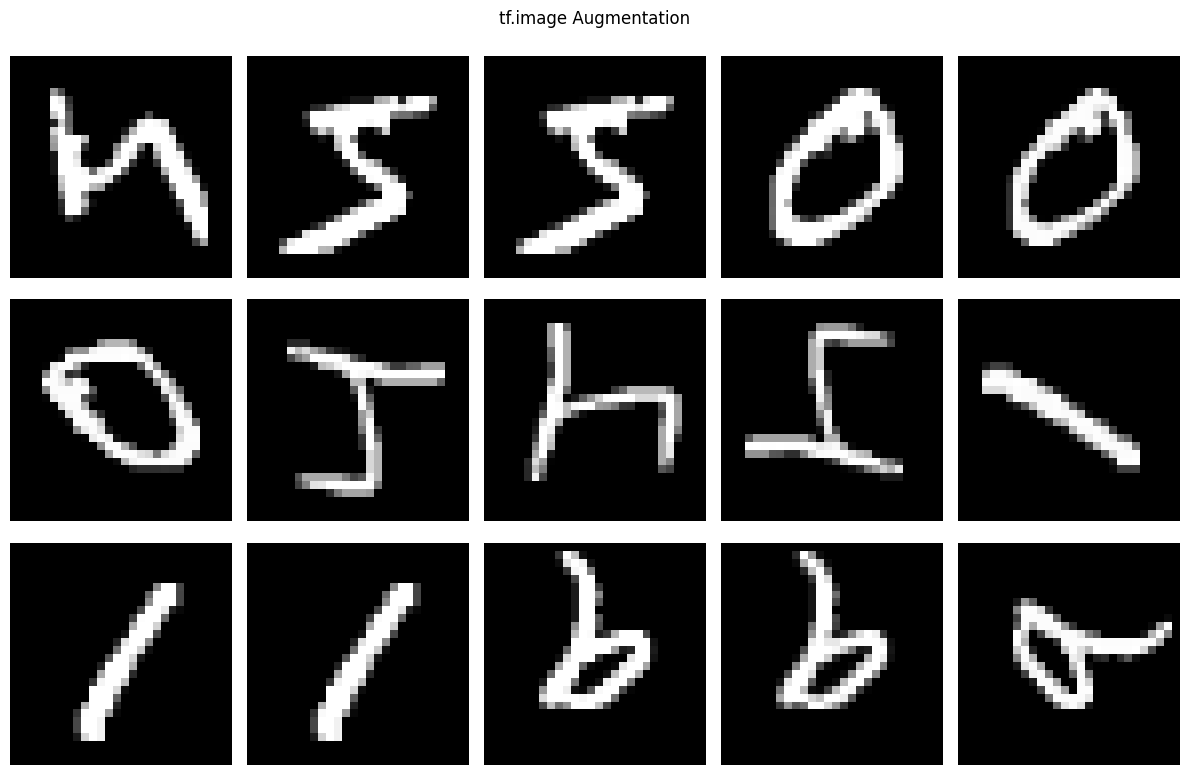

In [39]:
# Display tf.image augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_tf_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle('tf.image Augmentation')
plt.tight_layout()
plt.show()

In [40]:
# ----- 3. AUGMENTATION WITH OPENCV -----

def opencv_augment(image):
    # Convert to 0-255 range and uint8 for OpenCV
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Choose a random augmentation
    choice = np.random.choice(['rotate', 'blur', 'zoom', 'original'])

    if choice == 'rotate':
        # Random rotation
        angle = np.random.uniform(-15, 15)
        return ndimage.rotate(image, angle, reshape=False)

    elif choice == 'blur':
        # Add blur
        return cv2.GaussianBlur(image, (3, 3), 0)

    elif choice == 'zoom':
        # Random zoom
        zoom_factor = np.random.uniform(0.8, 1.2)
        height, width = image.shape

        # Compute new dimensions
        new_height = int(height * zoom_factor)
        new_width = int(width * zoom_factor)

        if zoom_factor < 1:  # Zoom out
            # Crop the image
            y_start = (height - new_height) // 2
            x_start = (width - new_width) // 2
            cropped = image[y_start:y_start+new_height, x_start:x_start+new_width]
            # Resize back to original size
            return cv2.resize(cropped, (width, height))
        else:  # Zoom in
            # Resize
            resized = cv2.resize(image, (new_width, new_height))
            # Crop to original size
            y_start = (new_height - height) // 2
            x_start = (new_width - width) // 2
            return resized[y_start:y_start+height, x_start:x_start+width]

    else:
        # Return original
        return image

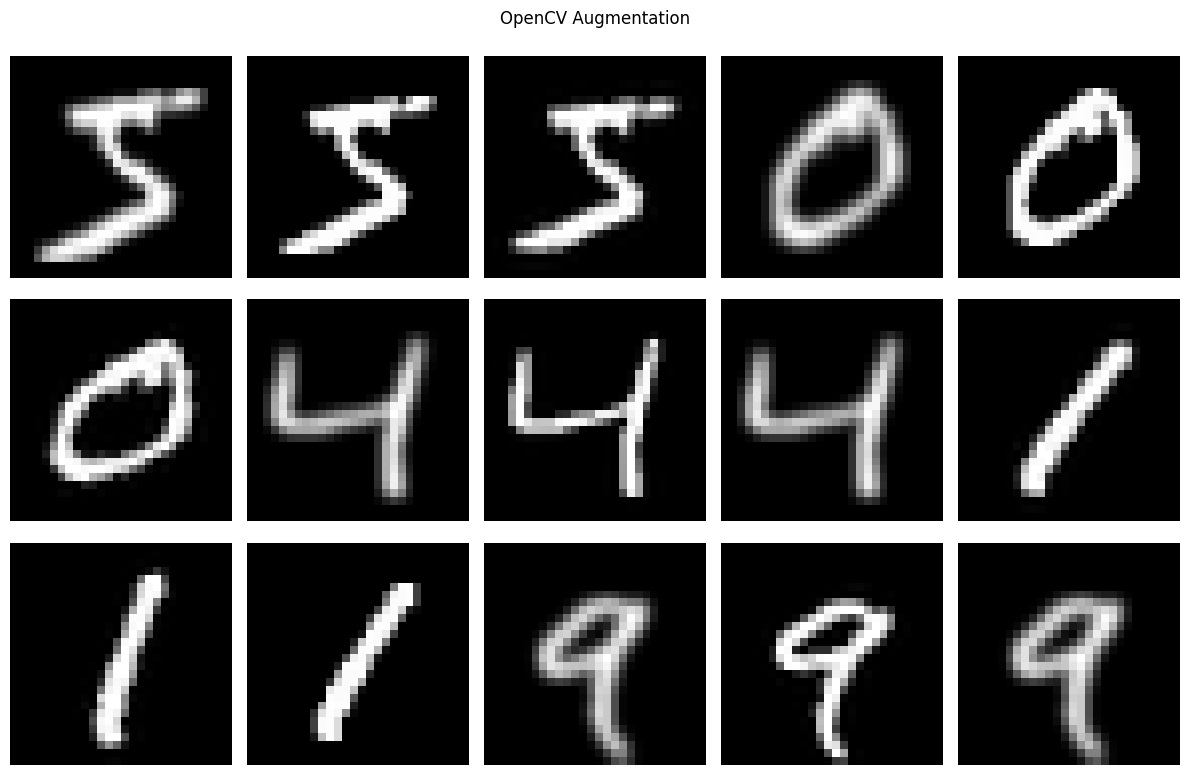

In [41]:

# Apply OpenCV augmentation
opencv_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = opencv_augment(X_train_img[i])
        # Normalize back to 0-1
        aug_img = aug_img.astype(np.float32) / 255.0
        opencv_augmented.append(aug_img)

# Display OpenCV augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(opencv_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('OpenCV Augmentation')
plt.tight_layout()
plt.show()

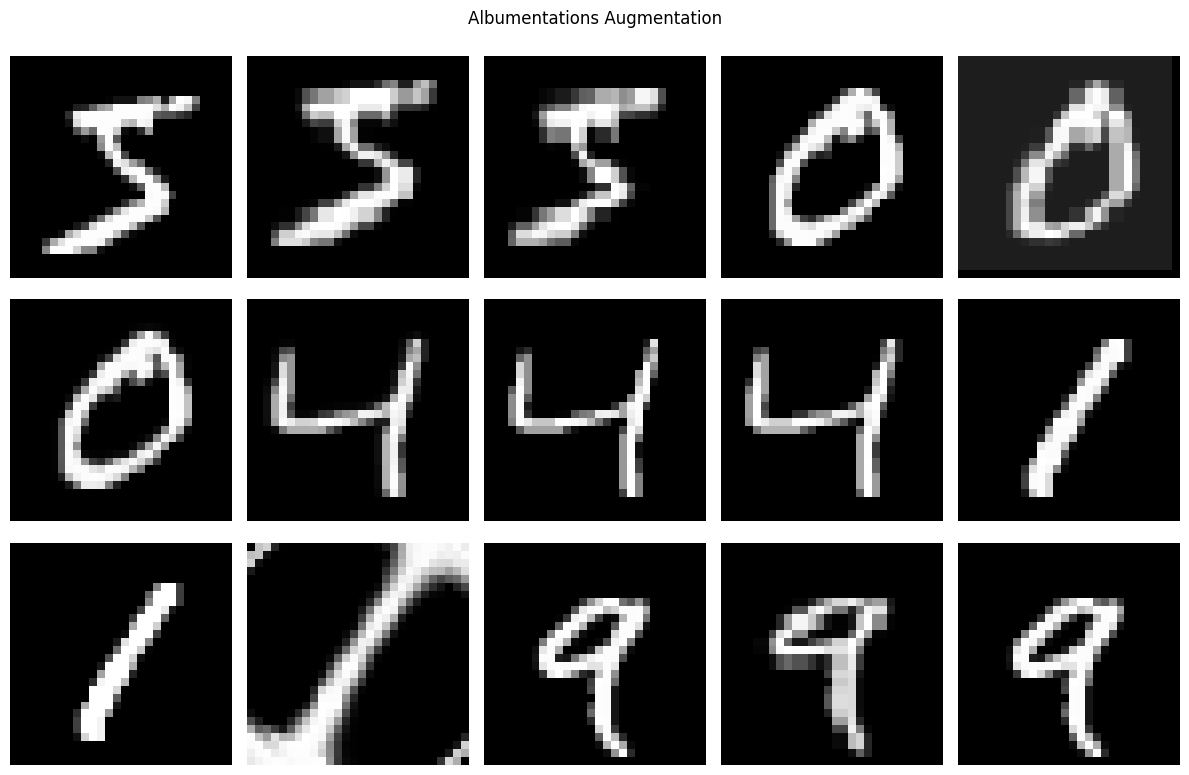

In [42]:
# ----- 4. AUGMENTATION WITH ALBUMENTATIONS -----

def apply_albumentation(image):
    # Convert to 0-255 range and uint8 for Albumentations
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Define transformation pipeline
    transform = A.Compose([
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.RandomGamma(p=0.8),
        ], p=0.5),
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5),
        ], p=0.5),
    ])

    # Apply transformation
    augmented = transform(image=image)['image']

    # Normalize back to 0-1
    return augmented.astype(np.float32) / 255.0

# Apply Albumentations
albu_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = apply_albumentation(X_train_img[i])
        albu_augmented.append(aug_img)

# Display Albumentations augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(albu_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Albumentations Augmentation')
plt.tight_layout()
plt.show()


In [43]:
# ----- 5. TEXT DATA AUGMENTATION -----

# Sample texts
texts = [
    "This is a great product, I love it!",
    "The service was terrible and I'm disappointed.",
    "I'm not sure how I feel about this experience.",
    "The food was delicious and the staff was friendly.",
    "This movie is boring and too long."
]

In [44]:
# Simple text augmentation techniques
def swap_words(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx1, idx2 = sorted(random.sample(range(len(words)), 2))
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def delete_random_word(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx = random.randrange(len(words))
    return ' '.join(words[:idx] + words[idx+1:])

def insert_random_word(text, word_list=["really", "very", "somewhat", "quite", "extremely"]):
    words = text.split()
    if not words:
        return text

    idx = random.randrange(len(words))
    word_to_insert = random.choice(word_list)
    return ' '.join(words[:idx] + [word_to_insert] + words[idx:])

In [45]:
# Apply text augmentation
import random
augmented_texts = []
for text in texts:
    augmented_texts.append(("Original", text))
    augmented_texts.append(("Word Swap", swap_words(text)))
    augmented_texts.append(("Word Deletion", delete_random_word(text)))
    augmented_texts.append(("Word Insertion", insert_random_word(text)))

In [46]:
# Display original and augmented texts
print("\nText Data Augmentation Examples:")
for aug_type, text in augmented_texts:
    print(f"{aug_type}: {text}")


Text Data Augmentation Examples:
Original: This is a great product, I love it!
Word Swap: This is a great product, love I it!
Word Deletion: This is a great product, love it!
Word Insertion: This somewhat is a great product, I love it!
Original: The service was terrible and I'm disappointed.
Word Swap: The and was terrible service I'm disappointed.
Word Deletion: The service was and I'm disappointed.
Word Insertion: The service was terrible and quite I'm disappointed.
Original: I'm not sure how I feel about this experience.
Word Swap: I'm not experience. how I feel about this sure
Word Deletion: I'm not sure how feel about this experience.
Word Insertion: I'm not sure how I feel about this extremely experience.
Original: The food was delicious and the staff was friendly.
Word Swap: the food was delicious and The staff was friendly.
Word Deletion: The food was delicious and the staff friendly.
Word Insertion: The food was delicious and the staff was somewhat friendly.
Original: This mo

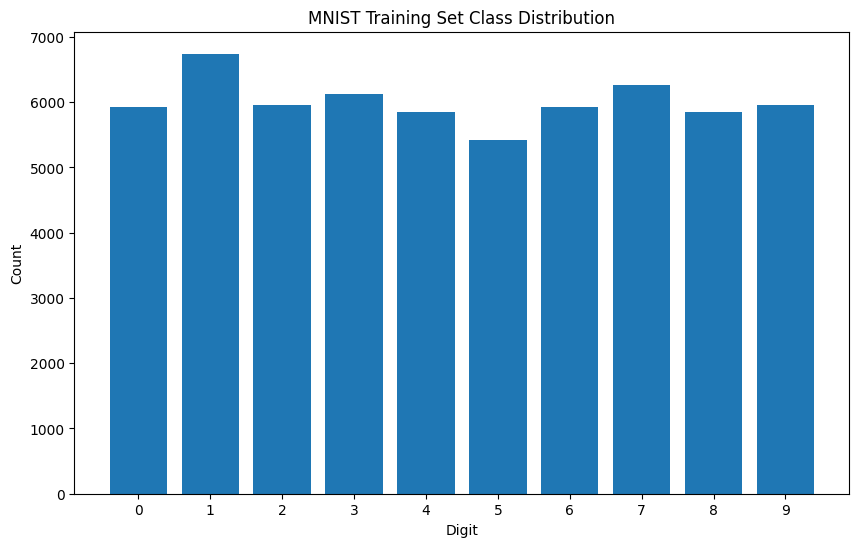

In [47]:
# ----- 6. ADVANCED APPLICATION: AUGMENT TO BALANCE CLASSES -----

# Check distribution of classes in MNIST
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Check distribution of classes
unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))

# Plot class distribution
plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('MNIST Training Set Class Distribution')
plt.xticks(unique)
plt.show()

In [48]:

def augment_minority_class(X, y, target_class, num_samples):
    # Find samples of the target class
    class_indices = np.where(y == target_class)[0]
    X_class = X[class_indices]

    # If we already have enough samples, no need to augment
    if len(X_class) >= num_samples:
        return X, y

    # Number of augmentations needed
    num_augmentations = num_samples - len(X_class)

    # Create augmentation generator
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Generate augmented images
    augmented_images = []
    augmented_labels = []

    for x_batch in datagen.flow(X_class, batch_size=1, shuffle=True):
        augmented_images.append(x_batch[0])
        augmented_labels.append(target_class)
        if len(augmented_images) >= num_augmentations:
            break

    # Convert to numpy arrays
    augmented_images = np.array(augmented_images)
    augmented_labels = np.array(augmented_labels)

    # Combine original and augmented data
    X_balanced = np.vstack([X, augmented_images])
    y_balanced = np.hstack([y, augmented_labels])

    return X_balanced, y_balanced

In [49]:
# Demonstrate balancing a subset of MNIST
# For demonstration, let's use just 100 samples per class initially

X_sample = []
y_sample = []

for digit in range(10):
    indices = np.where(y_train == digit)[0][:100]  # Take 100 samples of each digit
    X_sample.extend(x_train[indices])
    y_sample.extend(y_train[indices])

X_sample = np.array(X_sample)
y_sample = np.array(y_sample)

print("X_sample shape:", X_sample.shape)
print("y_sample distribution:", np.unique(y_sample, return_counts=True))

X_sample shape: (1000, 28, 28)
y_sample distribution: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([100, 100, 100, 100, 100, 100, 100, 100, 100, 100]))


In [50]:
# Print initial distribution
unique, counts = np.unique(y_sample, return_counts=True)
print("\nInitial distribution:")
print(dict(zip(unique, counts)))


Initial distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(100), np.uint8(9): np.int64(100)}


In [51]:
# Let's artificially create an imbalance by removing some '8' samples
eight_indices = np.where(y_sample == 8)[0]
remove_indices = eight_indices[:80]  # Remove 80 samples of digit 8
mask = np.ones(len(y_sample), dtype=bool)
mask[remove_indices] = False

X_imbalanced = X_sample[mask]
y_imbalanced = y_sample[mask]


In [52]:
# Print imbalanced distribution
unique, counts = np.unique(y_imbalanced, return_counts=True)
print("\nImbalanced distribution:")
print(dict(zip(unique, counts)))



Imbalanced distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(20), np.uint8(9): np.int64(100)}


In [63]:

# Add a channel dimension if images are grayscale
if X_imbalanced.ndim == 3:
    X_imbalanced = np.expand_dims(X_imbalanced, axis=-1)

# Balance the dataset
X_balanced, y_balanced = augment_minority_class(
    X_imbalanced, y_imbalanced, target_class=8, num_samples=100
)
unique, counts = np.unique(y_balanced, return_counts=True)

print("Balanced distribution after augmentation:")
print(dict(zip(unique, counts)))

print("Balanced data shape:", X_balanced.shape)

Balanced distribution after augmentation:
{np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100), np.int64(9): np.int64(100)}
Balanced data shape: (1000, 28, 28, 1)


In [64]:
# ----- 7. DEMONSTRATING THE EFFECT OF AUGMENTATION ON MODEL PERFORMANCE -----

# Create a simple CNN model for MNIST
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [65]:
# Train model on imbalanced data
model_imbalanced = create_model()
history_imbalanced = model_imbalanced.fit(X_imbalanced, y_imbalanced, epochs=5,
                                           validation_split=0.2, verbose=0)


In [66]:
# Train model on balanced data
model_balanced = create_model()
history_balanced = model_balanced.fit(X_balanced, y_balanced, epochs=5,
                                       validation_split=0.2, verbose=0)

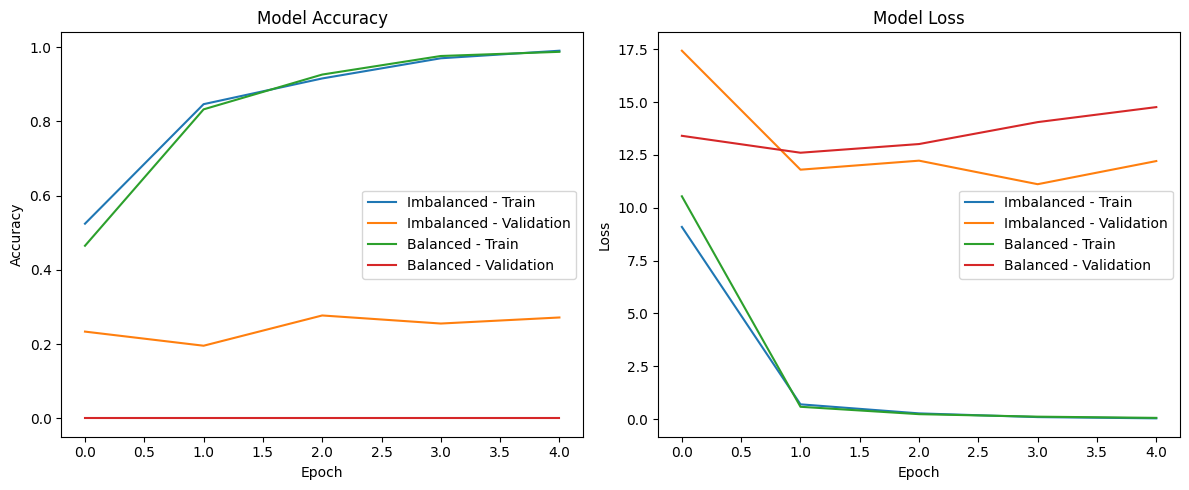

In [67]:
# Compare performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_imbalanced.history['accuracy'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_accuracy'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['accuracy'], label='Balanced - Train')
plt.plot(history_balanced.history['val_accuracy'], label='Balanced - Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imbalanced.history['loss'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_loss'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['loss'], label='Balanced - Train')
plt.plot(history_balanced.history['val_loss'], label='Balanced - Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Excercise

In [69]:
# 1. Setup and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# TODO: Load the Titanic dataset into `df` using pd.read_csv
# Hint: URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = None  # TODO
#Load Data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
# TODO: Display first 5 rows and the dataset shape
print("First 5 rows:")
print(df.head())
print("Dataset shape:", df.shape)

# TODO: Print missing value counts per column
print("Missing values per column:")
print(df.isnull().sum())


First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [70]:
# TODO: Fill missing 'Age' with its median
df['Age'].fillna(df['Age'].median(), inplace=True)

# TODO: Fill missing 'Embarked' with its mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# TODO: Replace missing 'Cabin' entries with 'Unknown'
df['Cabin'].fillna('Unknown', inplace=True)

print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [71]:
# 2. Missing Value Imputation

# 3.1 Extract Title from Name
# TODO: Create df['Title'] by extracting the substring before '.' in Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 3.2 Group rare titles into 'Rare' and standardize variants
rare_titles = [
    'Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major',
    'Rev', 'Sir', 'Jonkheer', 'Dona'
]
# TODO: Replace rare and variant titles accordingly
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})
# 3.3 Family Size and IsAlone
# TODO: df['FamilySize'] = SibSp + Parch + 1
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# TODO: df['IsAlone'] = 1 where FamilySize == 1, else 0
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

# 3.4 Fare Per Person
# TODO: df['FarePerPerson'] = Fare / FamilySize
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 3.5 Age and Fare Binning
# TODO: Create AgeBin categories: Child (0–12), Teenager (13–18), Adult (19–65), Elderly (>65)
df['AgeBin'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 65, np.inf],
    labels=['Child', 'Teenager', 'Adult', 'Elderly']
)
# TODO: Create FareBin quantiles: Low, Medium, High, Very High
df['FareBin'] = pd.qcut(
    df['Fare'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)
# 3.6 Deck from Cabin
# TODO: df['Deck'] = first letter of Cabin; replace 'Unknown'→'U' and rare letters→'Other'
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace('U', 'U')
deck_counts = df['Deck'].value_counts()
rare_decks = deck_counts[deck_counts < 10].index

df['Deck'] = df['Deck'].replace(rare_decks, 'Other')
print(df[['Title', 'FamilySize', 'IsAlone', 'FarePerPerson',
          'AgeBin', 'FareBin', 'Deck']].head())

  Title  FamilySize  IsAlone  FarePerPerson AgeBin    FareBin Deck
0    Mr           2        0        3.62500  Adult        Low    U
1   Mrs           2        0       35.64165  Adult  Very High    C
2  Miss           1        1        7.92500  Adult     Medium    U
3   Mrs           2        0       26.55000  Adult  Very High    C
4    Mr           1        1        8.05000  Adult     Medium    U


In [72]:
# 3. Feature Engineering

# 3.1 Extract Title from Name
# TODO: Create df['Title'] by extracting the substring before '.' in Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 3.2 Group rare titles into 'Rare' and standardize variants
rare_titles = [
    'Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
    'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'
]

# TODO: Replace rare and variant titles accordingly
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

# 3.3 Family Size and IsAlone
# TODO: df['FamilySize'] = SibSp + Parch + 1
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# TODO: df['IsAlone'] = 1 where FamilySize == 1, else 0

df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# 3.4 Fare Per Person
# TODO: df['FarePerPerson'] = Fare / FamilySize
df['FarePerPerson'] = df['Fare'] / df['FamilySize']


# 3.5 Age and Fare Binning
# TODO: Create AgeBin categories: Child (0–12), Teenager (13–18), Adult (19–65), Elderly (>65)
df['AgeBin'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 65, np.inf],
    labels=['Child', 'Teenager', 'Adult', 'Elderly']
)

# TODO: Create FareBin quantiles: Low, Medium, High, Very High
df['FareBin'] = pd.qcut(
    df['Fare'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# 3.6 Deck from Cabin
df['Deck'] = df['Cabin'].str[0]
# TODO: df['Deck'] = first letter of Cabin; replace 'Unknown'→'U' and rare letters→'Other'

df['Deck'] = df['Deck'].replace(np.nan, 'U')

deck_counts = df['Deck'].value_counts()
rare_decks = deck_counts[deck_counts < 10].index

df['Deck'] = df['Deck'].replace(rare_decks, 'Other')

# Check features
print(df[['Title', 'FamilySize', 'IsAlone',
          'FarePerPerson', 'AgeBin', 'FareBin', 'Deck']].head())


  Title  FamilySize  IsAlone  FarePerPerson AgeBin    FareBin Deck
0    Mr           2        0        3.62500  Adult        Low    U
1   Mrs           2        0       35.64165  Adult  Very High    C
2  Miss           1        1        7.92500  Adult     Medium    U
3   Mrs           2        0       26.55000  Adult  Very High    C
4    Mr           1        1        8.05000  Adult     Medium    U


In [75]:
# 4. Encoding and Scaling

# 4.1 One‑hot encode selected categorical columns using pd.get_dummies :contentReference[oaicite:11]{index=11}
categorical = ['Pclass','Sex','Embarked','Title','AgeBin','FareBin','Deck']
df_encoded = pd.get_dummies(df[categorical], drop_first=True)

# TODO: df_encoded = pd.get_dummies(df[categorical], drop_first=True)

# 4.2 Combine with numerical features
numerical = ['Age','SibSp','Parch','Fare','FamilySize','IsAlone','FarePerPerson']
# TODO: X = pd.concat([...], axis=1)
X = pd.concat([df[numerical], df_encoded], axis=1)

# TODO: y = df['Survived']
y = df['Survived']

X = X.astype(float)

# 4.3 Feature scaling: fit three different scalers and transform X
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# TODO: scaler_std = StandardScaler()       # :contentReference[oaicite:12]{index=12}
# TODO: X_std = scaler_std.fit_transform(X)
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

# TODO: scaler_mm  = MinMaxScaler()
# TODO: X_mm  = scaler_mm.fit_transform(X)
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)
# TODO: scaler_rbv = RobustScaler()
# TODO: X_rb  = scaler_rbv.fit_transform(X)
scaler_rbv = RobustScaler()
X_rb = scaler_rbv.fit_transform(X)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (891, 28)
Target shape: (891,)


In [78]:
# 5. Feature Selection & Modeling

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# TODO: Use SelectKBest(f_classif, k=15) to pick top features :contentReference[oaicite:13]{index=13}
selector = SelectKBest(score_func=f_classif, k=15)  # TODO
# TODO: X_sel = selector.fit_transform(X_std, y)
X_sel = selector.fit_transform(X_std, y)

# TODO: top_feats = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_}).nlargest(15,'Score')
top_feats = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).nlargest(15, 'Score')

print("Top 15 Features:")
print(top_feats)

# TODO: Split into train/test (25% test), train RandomForestClassifier, and print:
#       - Accuracy
#       - Classification report
X_train, X_test, y_train, y_test = train_test_split(
    X_sel,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Top 15 Features:
              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
27             Deck_U   99.253142
3                Fare   63.030764
20  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
21             Deck_B   28.117228
23             Deck_D   20.663186
10         Embarked_S   20.374460
24             Deck_E   19.179221
22             Deck_C   11.841661
Accuracy:
0.7713004484304933
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       137
           1       0.72      0.66      0.69        86

    accuracy                           0.77       223
   macro avg       0.76      0.75      0.75       223
weighted avg       0.77      0.77      0.77       223



Polynomial Feature Names:
['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']
Polynomial Feature Shape:
(891, 5)
Explained Variance Ratio:
[0.17143027 0.13213052 0.07901107 0.06937292 0.05782973 0.04735812
 0.0447626  0.04192034 0.03876175 0.03756467]
Cumulative Explained Variance:
[0.17143027 0.30356079 0.38257186 0.45194478 0.50977451 0.55713263
 0.60189523 0.64381557 0.68257732 0.72014198]


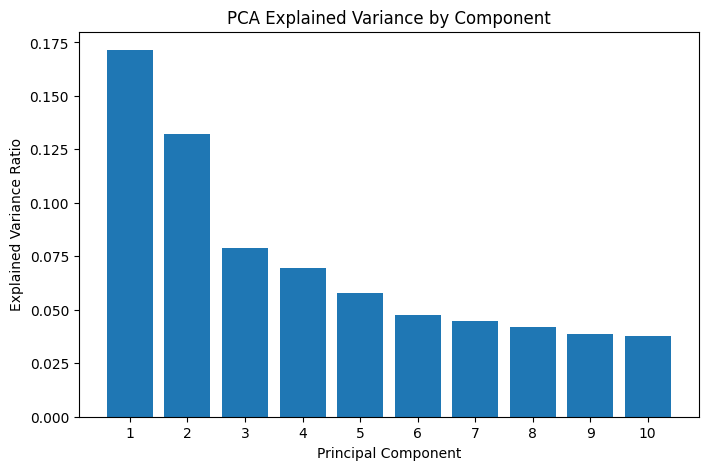

In [80]:
# 6. Advanced Feature Engineering

# 6.1 Polynomial Features using sklearn.preprocessing.PolynomialFeatures :contentReference[oaicite:14]{index=14}
from sklearn.preprocessing import PolynomialFeatures
# TODO: poly = PolynomialFeatures(degree=2, include_bias=False)
poly = PolynomialFeatures(degree=2, include_bias=False)

# TODO: poly_data = poly.fit_transform(df[['Age','Fare']].fillna(0))
poly_data = poly.fit_transform(df[['Age', 'Fare']].fillna(0))

# TODO: print(poly.get_feature_names_out(['Age','Fare']))
print("Polynomial Feature Names:")
print(poly.get_feature_names_out(['Age', 'Fare']))

print("Polynomial Feature Shape:")
print(poly_data.shape)

# 6.2 PCA for dimensionality reduction :contentReference[oaicite:15]{index=15}
from sklearn.decomposition import PCA
# TODO: pca = PCA(n_components=10)
pca = PCA(n_components=10)

# TODO: X_pca = pca.fit_transform(X_std)
X_pca = pca.fit_transform(X_std)

# TODO: Plot explained variance ratio bar chart
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# TODO: Print cumulative variance (np.cumsum)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("Cumulative Explained Variance:")
print(cumulative_variance)

plt.figure(figsize=(8, 5))
plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance by Component")
plt.xticks(range(1, 11))
plt.show()


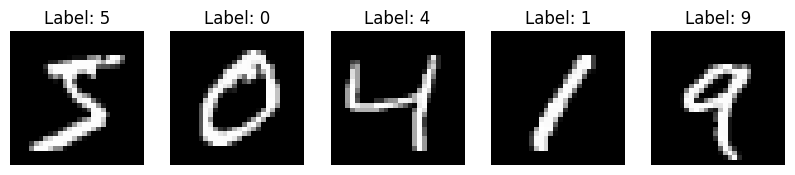

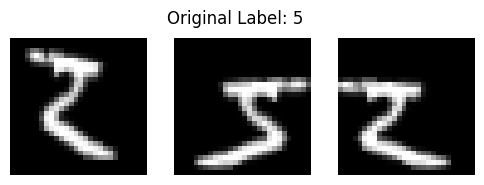

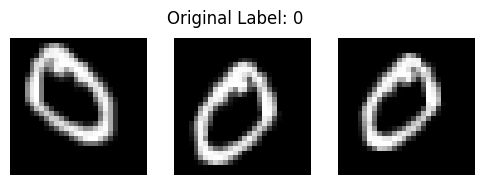

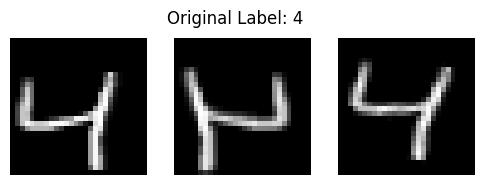

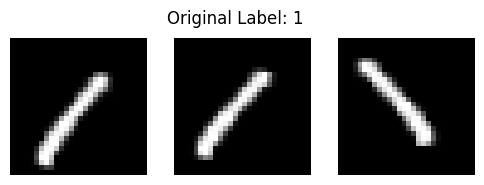

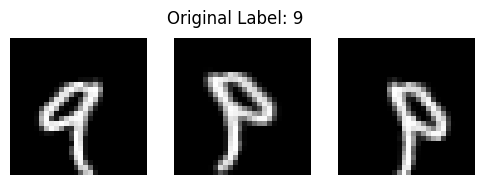

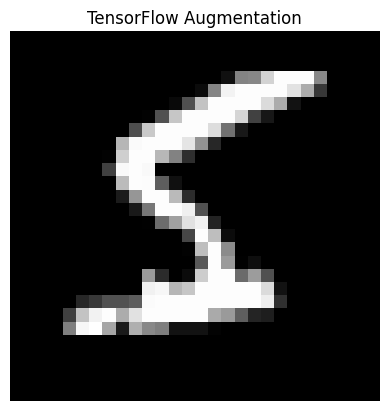

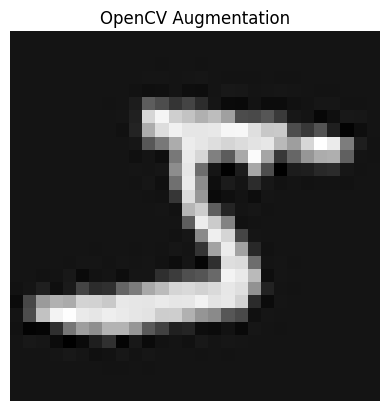

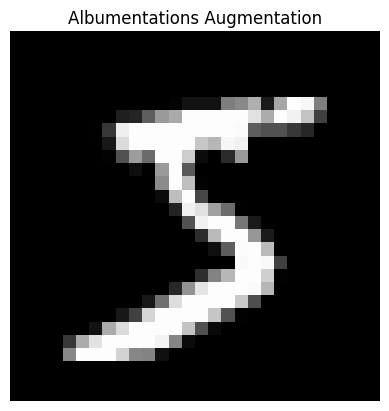

Original Text:
This movie was very interesting
1. Swap Words:
This was movie very interesting
2. Delete Random Word:
This movie was interesting
3. Insert Random Word:
This amazing movie was very interesting
Original Text:
The food was delicious and tasty
1. Swap Words:
tasty food was delicious and The
2. Delete Random Word:
The food delicious and tasty
3. Insert Random Word:
The food interesting was delicious and tasty
Original Text:
Machine learning is useful
1. Swap Words:
learning Machine is useful
2. Delete Random Word:
Machine is useful
3. Insert Random Word:
Machine learning really is useful


In [88]:
# 7. Image Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator  # :contentReference[oaicite:16]{index=16}
from tensorflow.keras.datasets import mnist

# TODO: Load MNIST, normalize, and reshape to (28,28,1)
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype("float32") / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)

# TODO: Display 5 sample images with true labels
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.show()

# 7.1 Keras ImageDataGenerator
datagen = ImageDataGenerator(rotation_range=10,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             zoom_range=0.1,
                             shear_range=0.1,
                             horizontal_flip=True,
                             fill_mode='nearest')
# TODO: Generate and plot 3 augmentations per sample for first 5 images
for i in range(5):
    img = X_train[i].reshape(1, 28, 28, 1)

    aug_iter = datagen.flow(img, batch_size=1)

    plt.figure(figsize=(6, 2))
    plt.suptitle(f"Original Label: {y_train[i]}")

    for j in range(3):
        aug_img = next(aug_iter)[0]

        plt.subplot(1, 3, j + 1)
        plt.imshow(aug_img.squeeze(), cmap="gray")
        plt.axis("off")

    plt.show()


# 7.2 tf.image augmentations :contentReference[oaicite:17]{index=17}
# TODO: Write a function using tf.image.rot90, tf.image.random_brightness, tf.image.random_contrast
import tensorflow as tf
def tf_augment(image):
    image = tf.image.rot90(image, k=np.random.randint(1, 4))
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    return tf.clip_by_value(image, 0, 1)
aug_img = tf_augment(X_train[0])

plt.imshow(aug_img.numpy().squeeze(), cmap="gray")
plt.title("TensorFlow Augmentation")
plt.axis("off")
plt.show()


# 7.3 OpenCV augmentations :contentReference[oaicite:18]{index=18}
import cv2
from scipy import ndimage
import numpy as np
# TODO: Write opencv_augment() that randomly applies rotate, blur, or zoom
def opencv_augment(image):
    img = image.squeeze()

    choice = np.random.choice(["rotate", "blur", "zoom"])

    if choice == "rotate":
        angle = np.random.randint(-20, 20)
        img = ndimage.rotate(img, angle, reshape=False)

    elif choice == "blur":
        img = cv2.GaussianBlur(img, (3, 3), 0)

    elif choice == "zoom":
        zoom_factor = np.random.uniform(0.8, 1.2)

        h, w = img.shape
        zoomed = cv2.resize(
            img,
            None,
            fx=zoom_factor,
            fy=zoom_factor
        )

        zh, zw = zoomed.shape

        if zoom_factor < 1:
            result = np.zeros((h, w))
            start_h = (h - zh) // 2
            start_w = (w - zw) // 2
            result[start_h:start_h+zh, start_w:start_w+zw] = zoomed
            img = result
        else:
            start_h = (zh - h) // 2
            start_w = (zw - w) // 2
            img = zoomed[start_h:start_h+h, start_w:start_w+w]

    return img.reshape(28, 28, 1)
cv_img = opencv_augment(X_train[0])

plt.imshow(cv_img.squeeze(), cmap="gray")
plt.title("OpenCV Augmentation")
plt.axis("off")
plt.show()

# 7.4 Albumentations pipeline :contentReference[oaicite:19]{index=19}
import albumentations as A
# TODO: Define A.Compose with RandomBrightnessContrast, ElasticTransform, GridDistortion, OpticalDistortion
transform = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.ElasticTransform(p=0.5),
    A.GridDistortion(p=0.5),
    A.OpticalDistortion(p=0.5)
])
image = X_train[0].squeeze()

augmented = transform(image=image)

plt.imshow(augmented["image"], cmap="gray")
plt.title("Albumentations Augmentation")
plt.axis("off")
plt.show()

# TODO: Implement swap_words(text), delete_random_word(text), insert_random_word(text)
#SWAP
def swap_words(text):
    words = text.split()

    if len(words) < 2:
        return text

    i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]

    return " ".join(words)

#DELETION
def delete_random_word(text):
    words = text.split()

    if len(words) == 0:
        return text

    index = random.randint(0, len(words)-1)
    words.pop(index)

    return " ".join(words)

# Insertion
def insert_random_word(text):
    words = text.split()

    random_words = [
        "very", "really", "good",
        "bad", "interesting", "amazing"
    ]

    new_word = random.choice(random_words)
    index = random.randint(0, len(words))

    words.insert(index, new_word)

    return " ".join(words)


# TODO: For each original text, print the 3 augmented variants
texts = [
    "This movie was very interesting",
    "The food was delicious and tasty",
    "Machine learning is useful"
]

for text in texts:
    print("Original Text:")
    print(text)

    print("1. Swap Words:")
    print(swap_words(text))

    print("2. Delete Random Word:")
    print(delete_random_word(text))

    print("3. Insert Random Word:")
    print(insert_random_word(text))

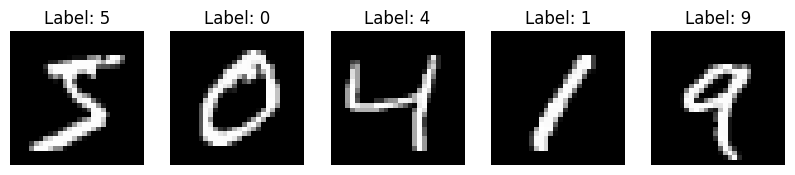

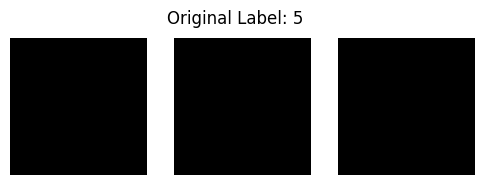

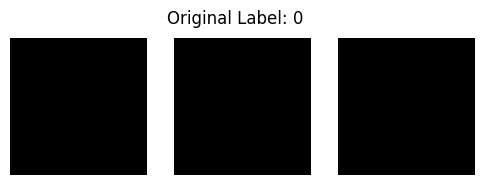

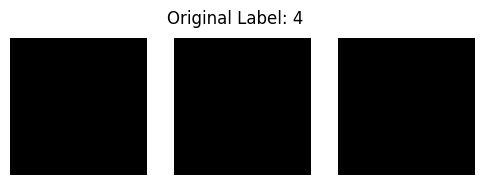

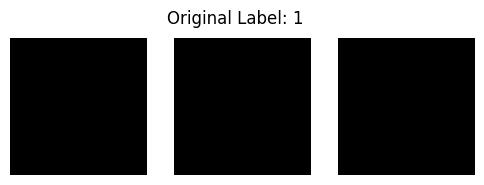

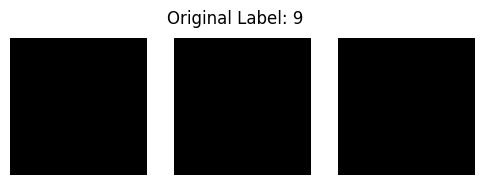

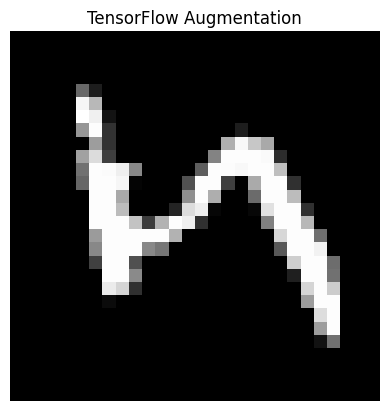

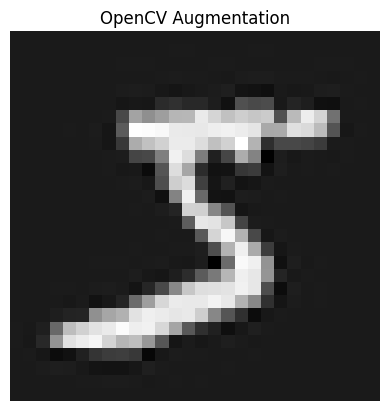

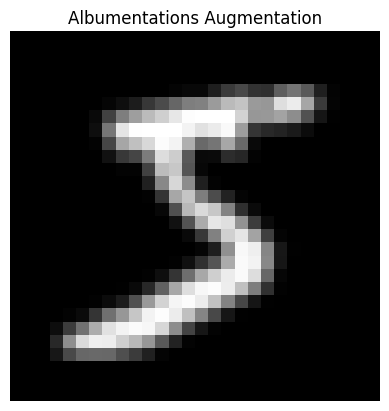

Original Text:
This movie was very interesting
1. Swap Words:
very movie was This interesting
2. Delete Random Word:
movie was very interesting
3. Insert Random Word:
This movie was very good interesting
Original Text:
The food was delicious and tasty
1. Swap Words:
The food delicious was and tasty
2. Delete Random Word:
The was delicious and tasty
3. Insert Random Word:
The food was delicious good and tasty
Original Text:
Machine learning is useful
1. Swap Words:
Machine useful is learning
2. Delete Random Word:
Machine learning is
3. Insert Random Word:
Machine learning really is useful


In [87]:
# 8. Text Data Augmentation

import random  # :contentReference[oaicite:20]{index=20}

# Sample sentences provided
texts = [...]# 7. Image Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator  # :contentReference[oaicite:16]{index=16}
from tensorflow.keras.datasets import mnist

# TODO: Load MNIST, normalize, and reshape to (28,28,1)
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype("float32") / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)

# TODO: Display 5 sample images with true labels
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.show()

# 7.1 Keras ImageDataGenerator
datagen = ImageDataGenerator(rotation_range=10,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             zoom_range=0.1,
                             shear_range=0.1,
                             brightness_range=[0.5,1.5],
                             horizontal_flip=True,
                             fill_mode='nearest')
# TODO: Generate and plot 3 augmentations per sample for first 5 images
for i in range(5):
    img = X_train[i].reshape(1, 28, 28, 1)

    aug_iter = datagen.flow(img, batch_size=1)

    plt.figure(figsize=(6, 2))
    plt.suptitle(f"Original Label: {y_train[i]}")

    for j in range(3):
        aug_img = next(aug_iter)[0]

        plt.subplot(1, 3, j + 1)
        plt.imshow(aug_img.squeeze(), cmap="gray")
        plt.axis("off")

    plt.show()


# 7.2 tf.image augmentations :contentReference[oaicite:17]{index=17}
# TODO: Write a function using tf.image.rot90, tf.image.random_brightness, tf.image.random_contrast
import tensorflow as tf
def tf_augment(image):
    image = tf.image.rot90(image, k=np.random.randint(1, 4))
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    return tf.clip_by_value(image, 0, 1)
aug_img = tf_augment(X_train[0])

plt.imshow(aug_img.numpy().squeeze(), cmap="gray")
plt.title("TensorFlow Augmentation")
plt.axis("off")
plt.show()


# 7.3 OpenCV augmentations :contentReference[oaicite:18]{index=18}
import cv2
from scipy import ndimage
import numpy as np
# TODO: Write opencv_augment() that randomly applies rotate, blur, or zoom
def opencv_augment(image):
    img = image.squeeze()

    choice = np.random.choice(["rotate", "blur", "zoom"])

    if choice == "rotate":
        angle = np.random.randint(-20, 20)
        img = ndimage.rotate(img, angle, reshape=False)

    elif choice == "blur":
        img = cv2.GaussianBlur(img, (3, 3), 0)

    elif choice == "zoom":
        zoom_factor = np.random.uniform(0.8, 1.2)

        h, w = img.shape
        zoomed = cv2.resize(
            img,
            None,
            fx=zoom_factor,
            fy=zoom_factor
        )

        zh, zw = zoomed.shape

        if zoom_factor < 1:
            result = np.zeros((h, w))
            start_h = (h - zh) // 2
            start_w = (w - zw) // 2
            result[start_h:start_h+zh, start_w:start_w+zw] = zoomed
            img = result
        else:
            start_h = (zh - h) // 2
            start_w = (zw - w) // 2
            img = zoomed[start_h:start_h+h, start_w:start_w+w]

    return img.reshape(28, 28, 1)
cv_img = opencv_augment(X_train[0])

plt.imshow(cv_img.squeeze(), cmap="gray")
plt.title("OpenCV Augmentation")
plt.axis("off")
plt.show()

# 7.4 Albumentations pipeline :contentReference[oaicite:19]{index=19}
import albumentations as A
# TODO: Define A.Compose with RandomBrightnessContrast, ElasticTransform, GridDistortion, OpticalDistortion
transform = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.ElasticTransform(p=0.5),
    A.GridDistortion(p=0.5),
    A.OpticalDistortion(p=0.5)
])
image = X_train[0].squeeze()

augmented = transform(image=image)

plt.imshow(augmented["image"], cmap="gray")
plt.title("Albumentations Augmentation")
plt.axis("off")
plt.show()

# TODO: Implement swap_words(text), delete_random_word(text), insert_random_word(text)
#SWAP
def swap_words(text):
    words = text.split()

    if len(words) < 2:
        return text

    i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]

    return " ".join(words)

#DELETION
def delete_random_word(text):
    words = text.split()

    if len(words) == 0:
        return text

    index = random.randint(0, len(words)-1)
    words.pop(index)

    return " ".join(words)

# Insertion
def insert_random_word(text):
    words = text.split()

    random_words = [
        "very", "really", "good",
        "bad", "interesting", "amazing"
    ]

    new_word = random.choice(random_words)
    index = random.randint(0, len(words))

    words.insert(index, new_word)

    return " ".join(words)


# TODO: For each original text, print the 3 augmented variants
texts = [
    "This movie was very interesting",
    "The food was delicious and tasty",
    "Machine learning is useful"
]

for text in texts:
    print("Original Text:")
    print(text)

    print("1. Swap Words:")
    print(swap_words(text))

    print("2. Delete Random Word:")
    print(delete_random_word(text))

    print("3. Insert Random Word:")
    print(insert_random_word(text))


In [99]:
# 9. Class Balancing via Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Compute class distribution of y_train_img
unique, counts = np.unique(y_train_img, return_counts=True)

print("Original class distribution:")
print(dict(zip(unique, counts)))


# Write augment_minority_class(X, y, target_class, num_samples)
def augment_minority_class(X, y, target_class, num_samples):

    # Finds indices for target_class
    class_indices = np.where(y == target_class)[0]

    X_class = X[class_indices]
    y_class = y[class_indices]

    # Uses ImageDataGenerator.flow to generate until desired count
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        shear_range=0.1,
        fill_mode='nearest'
    )

    X_augmented = []
    y_augmented = []

    flow = datagen.flow(
        X_class,
        y_class,
        batch_size=1,
        shuffle=True
    )

    current_count = len(X_class)

    while current_count < num_samples:
        img, label = next(flow)

        X_augmented.append(img[0])
        y_augmented.append(label[0])

        current_count += 1

    # Returns augmented X_balanced, y_balanced
    if len(X_augmented) > 0:
        X_augmented = np.array(X_augmented)
        y_augmented = np.array(y_augmented)

        X_balanced = np.concatenate(
            [X, X_augmented],
            axis=0
        )

        y_balanced = np.concatenate(
            [y, y_augmented],
            axis=0
        )

    else:
        X_balanced = X
        y_balanced = y

    return X_balanced, y_balanced

Original class distribution:
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


In [100]:
# Example: balance class 8 to 100 samples
X_balanced, y_balanced = augment_minority_class(
    X_train_img,
    y_train_img,
    target_class=8,
    num_samples=100
)


# Check new distribution
unique, counts = np.unique(y_balanced, return_counts=True)

print("\nBalanced class distribution:")
print(dict(zip(unique, counts)))


Balanced class distribution:
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5625 - loss: 1.4144 - val_accuracy: 0.2554 - val_loss: 5.9305
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8682 - loss: 0.4093 - val_accuracy: 0.2772 - val_loss: 8.5993
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9389 - loss: 0.2282 - val_accuracy: 0.2826 - val_loss: 8.2903
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9402 - loss: 0.1745 - val_accuracy: 0.2826 - val_loss: 8.3749
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9660 - loss: 0.1189 - val_accuracy: 0.3098 - val_loss: 8.3930
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9742 - loss: 0.0871 - val_accuracy: 0.3043 - val_loss: 8.7145
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9864 - loss: 0.0523 - val_accuracy: 0.2989 - val_loss: 9.7398
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9932 - loss: 0.0382 - val_accuracy: 0.3043 - v

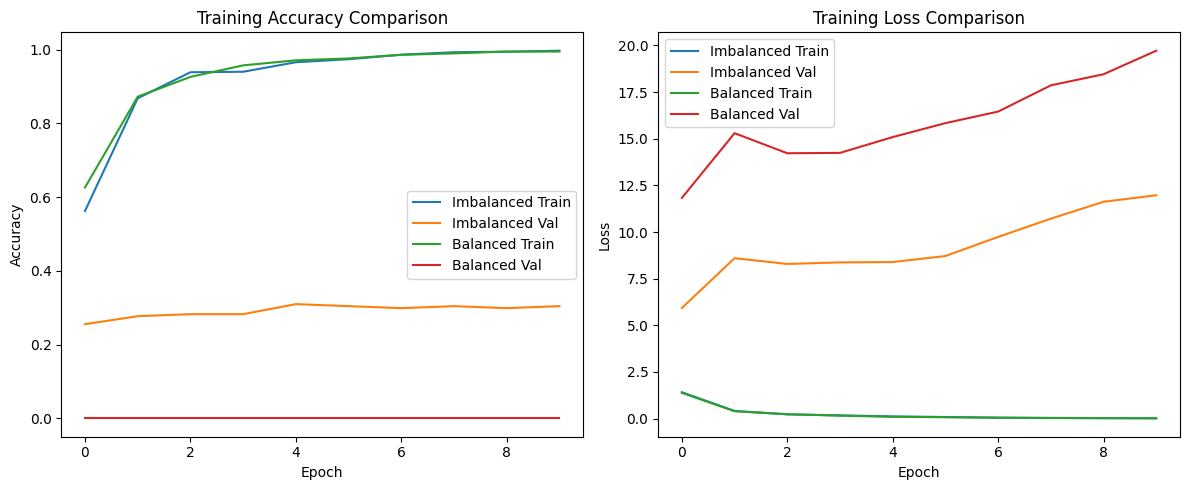

In [101]:
# 10. Effect of Augmentation on Model Performance

import tensorflow as tf

# TODO: Define create_model() as simple CNN
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(
            32, (3, 3),
            activation='relu',
            input_shape=(28, 28, 1)
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(
            64, (3, 3),
            activation='relu'
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            128,
            activation='relu'
        ),

        tf.keras.layers.Dense(
            10,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model
# TODO: Train on imbalanced subset (e.g. first 100 per class minus some for class '8')
X_imbalanced = []
y_imbalanced = []

for cls in range(10):
    indices = np.where(y_train_img == cls)[0]

    # Reduce class 8 samples
    if cls == 8:
        indices = indices[:20]
    else:
        indices = indices[:100]

    X_imbalanced.extend(X_train_img[indices])
    y_imbalanced.extend(y_train_img[indices])

X_imbalanced = np.array(X_imbalanced)
y_imbalanced = np.array(y_imbalanced)

model_imbalanced = create_model()

history_imbalanced = model_imbalanced.fit(
    X_imbalanced,
    y_imbalanced,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

# TODO: Train on balanced data after augmentation
X_balanced, y_balanced = augment_minority_class(
    X_imbalanced,
    y_imbalanced,
    target_class=8,
    num_samples=100
)
model_balanced = create_model()

history_balanced = model_balanced.fit(
    X_balanced,
    y_balanced,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

# TODO: Plot training/validation accuracy and loss side by side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_imbalanced.history['accuracy'], label='Imbalanced Train')
plt.plot(history_imbalanced.history['val_accuracy'], label='Imbalanced Val')

plt.plot(history_balanced.history['accuracy'], label='Balanced Train')
plt.plot(history_balanced.history['val_accuracy'], label='Balanced Val')

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(history_imbalanced.history['loss'], label='Imbalanced Train')
plt.plot(history_imbalanced.history['val_loss'], label='Imbalanced Val')

plt.plot(history_balanced.history['loss'], label='Balanced Train')
plt.plot(history_balanced.history['val_loss'], label='Balanced Val')

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

**Experiment: feel free to tweak parameters (e.g., k in SelectKBest, PCA components, augmentation ranges) to see their impact.**

In [105]:
# Experiment: Parameter tuning

# 1. Change SelectKBest parameter (k)
for k in [5, 10, 15, 20]:
    selector_exp = SelectKBest(score_func=f_classif, k=k)
    X_sel_exp = selector_exp.fit_transform(X_std, y)

    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_sel_exp,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    model_exp = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model_exp.fit(X_train_exp, y_train_exp)

    acc = model_exp.score(X_test_exp, y_test_exp)

    print(f"SelectKBest k={k} Accuracy: {acc:.4f}")


# 2. Experiment with PCA components
for components in [5, 10, 15, 20]:
    pca_exp = PCA(n_components=components)

    X_pca_exp = pca_exp.fit_transform(X_std)

    print(
        f"PCA components={components}, "
        f"Cumulative variance={np.sum(pca_exp.explained_variance_ratio_):.4f}"
    )


# 3. Experiment with augmentation strength

datagen_strong = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    brightness_range=[0.3, 1.7],
    fill_mode='nearest'
)

print("Experiment completed with different augmentation ranges.")

SelectKBest k=5 Accuracy: 0.7444
SelectKBest k=10 Accuracy: 0.7668
SelectKBest k=15 Accuracy: 0.7713
SelectKBest k=20 Accuracy: 0.7803
PCA components=5, Cumulative variance=0.5098
PCA components=10, Cumulative variance=0.7201
PCA components=15, Cumulative variance=0.8889
PCA components=20, Cumulative variance=0.9746
Experiment completed with different augmentation ranges.


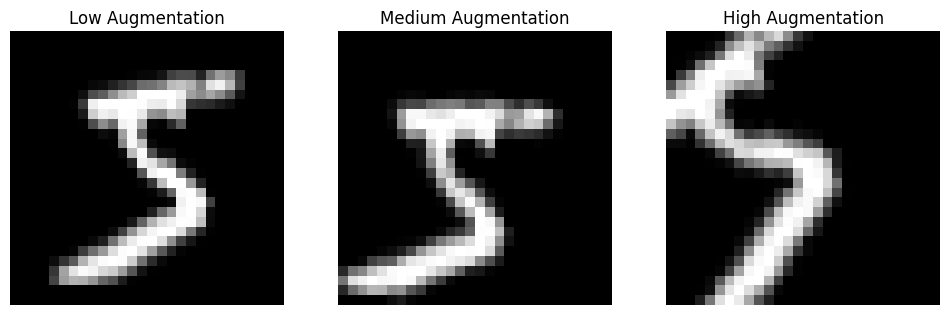

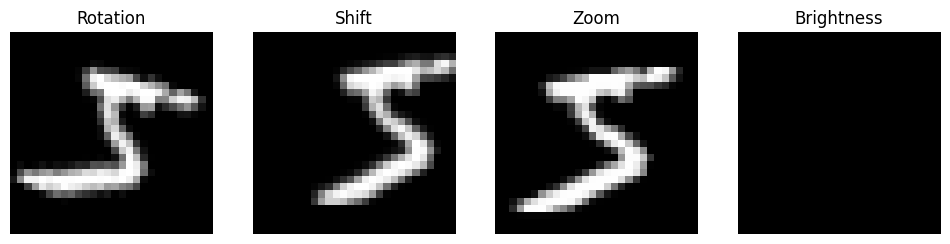

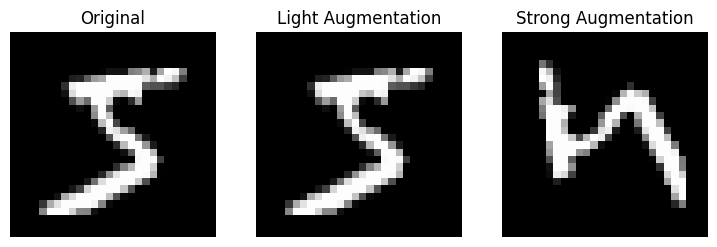


Original:
machine learning improves classification
Swap:
machine learning classification improves
Delete:
machine improves classification
Insert:
machine learning improves really classification

Original:
data augmentation improves model performance
Swap:
data improves augmentation model performance
Delete:
augmentation improves model performance
Insert:
data augmentation improves amazing model performance

Original:
deep learning needs more examples
Swap:
needs learning deep more examples
Delete:
deep learning needs more
Insert:
deep learning needs more examples really


In [106]:
# Import required libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import random


# Create different augmentation levels to compare image changes
augmentation_types = {
    "Low Augmentation": ImageDataGenerator(
        rotation_range=5,
        zoom_range=0.05,
        fill_mode='nearest'
    ),

    "Medium Augmentation": ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        fill_mode='nearest'
    ),

    "High Augmentation": ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.3,
        shear_range=0.2,
        fill_mode='nearest'
    )
}


# Select one image and create augmented versions
sample_image = X_train[0].reshape(1, 28, 28, 1)

plt.figure(figsize=(12,4))

i = 1

for name, generator in augmentation_types.items():

    # Generate a new augmented image
    img = next(generator.flow(sample_image, batch_size=1))[0]

    # Display augmented image
    plt.subplot(1,3,i)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(name)
    plt.axis("off")

    i += 1

plt.show()



# Compare individual augmentation techniques
methods = {
    "Rotation": ImageDataGenerator(rotation_range=30),
    "Shift": ImageDataGenerator(
        width_shift_range=0.2,
        height_shift_range=0.2
    ),
    "Zoom": ImageDataGenerator(zoom_range=0.3),
    "Brightness": ImageDataGenerator(
        brightness_range=[0.3,1.7]
    )
}


plt.figure(figsize=(12,4))

i = 1

for name, generator in methods.items():

    # Apply one augmentation method
    img = next(generator.flow(sample_image, batch_size=1))[0]

    # Show result
    plt.subplot(1,4,i)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(name)
    plt.axis("off")

    i += 1

plt.show()



# Apply simple TensorFlow image augmentation
def light_tf_augment(image):

    # Change image brightness slightly
    image = tf.image.random_brightness(
        image,
        max_delta=0.1
    )

    return image



# Apply stronger TensorFlow augmentation
def strong_tf_augment(image):

    # Rotate image and change brightness and contrast
    image = tf.image.rot90(image)

    image = tf.image.random_brightness(
        image,
        max_delta=0.3
    )

    image = tf.image.random_contrast(
        image,
        0.5,
        1.5
    )

    return tf.clip_by_value(image,0,1)



# Display TensorFlow augmentation results
light_img = light_tf_augment(X_train[0])
strong_img = strong_tf_augment(X_train[0])

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(X_train[0].squeeze(), cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(light_img.numpy().squeeze(), cmap='gray')
plt.title("Light Augmentation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(strong_img.numpy().squeeze(), cmap='gray')
plt.title("Strong Augmentation")
plt.axis("off")

plt.show()



# Create functions for text augmentation

# Swap two words randomly
def swap_words(text):

    words = text.split()

    if len(words) < 2:
        return text

    a, b = random.sample(range(len(words)), 2)

    words[a], words[b] = words[b], words[a]

    return " ".join(words)



# Remove one random word
def delete_random_word(text):

    words = text.split()

    if len(words) == 0:
        return text

    words.pop(random.randint(0,len(words)-1))

    return " ".join(words)



# Insert a random word
def insert_random_word(text):

    words = text.split()

    new_words = [
        "very",
        "really",
        "good",
        "amazing"
    ]

    words.insert(
        random.randint(0,len(words)),
        random.choice(new_words)
    )

    return " ".join(words)



# Test text augmentation on sample sentences
texts = [
    "machine learning improves classification",
    "data augmentation improves model performance",
    "deep learning needs more examples"
]


for text in texts:

    print("\nOriginal:")
    print(text)

    print("Swap:")
    print(swap_words(text))

    print("Delete:")
    print(delete_random_word(text))

    print("Insert:")
    print(insert_random_word(text))

Augmented class 8 to 50 samples -> Validation Accuracy: 0.1895
Augmented class 8 to 100 samples -> Validation Accuracy: 0.0000
Augmented class 8 to 200 samples -> Validation Accuracy: 0.4045
Augmented class 8 to 500 samples -> Validation Accuracy: 0.9857


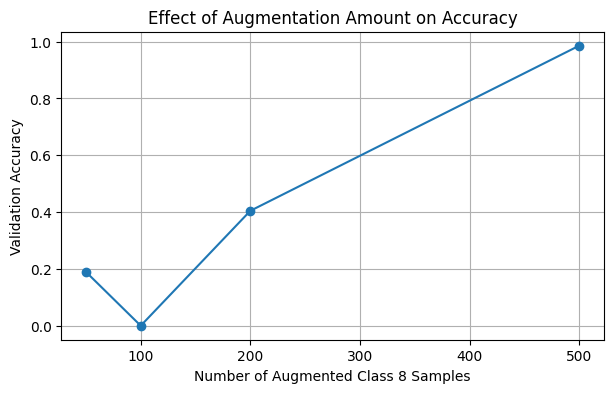

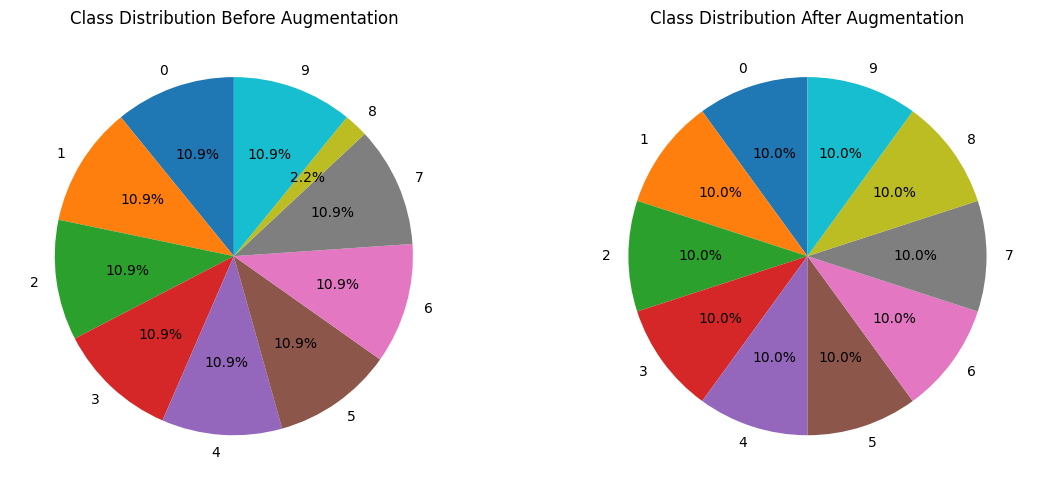

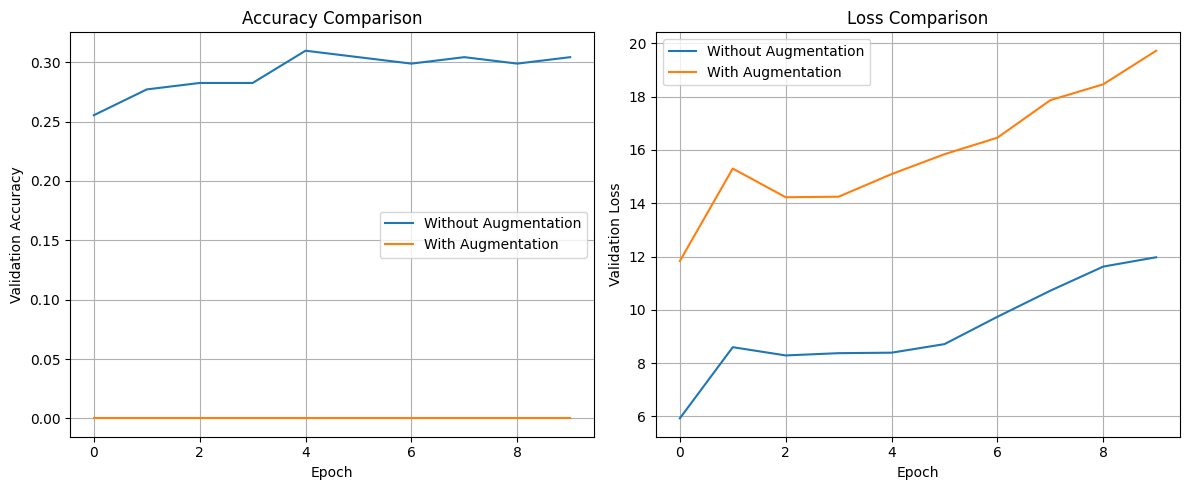

In [107]:
# 10. Additional Experiments

import matplotlib.pyplot as plt
import numpy as np


#Different augmentation sizes

augmentation_sizes = [50, 100, 200, 500]
results = []

for size in augmentation_sizes:

    X_bal_exp, y_bal_exp = augment_minority_class(
        X_imbalanced,
        y_imbalanced,
        target_class=8,
        num_samples=size
    )

    model_exp = create_model()
    history_exp = model_exp.fit(
        X_bal_exp,
        y_bal_exp,
        epochs=5,
        validation_split=0.2,
        verbose=0
    )

    accuracy = history_exp.history['val_accuracy'][-1]
    results.append(accuracy)

    print(
        f"Augmented class 8 to {size} samples -> "
        f"Validation Accuracy: {accuracy:.4f}"
    )

# Plot augmentation experiment results
plt.figure(figsize=(7,4))

plt.plot(
    augmentation_sizes,
    results,
    marker='o'
)

plt.xlabel("Number of Augmented Class 8 Samples")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Augmentation Amount on Accuracy")
plt.grid(True)

plt.show()

#Class Distribution Pie Chart
# Before augmentation
before_unique, before_counts = np.unique(
    y_imbalanced,
    return_counts=True
)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

plt.pie(
    before_counts,
    labels=before_unique,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Class Distribution Before Augmentation")

# After augmentation
after_unique, after_counts = np.unique(
    y_balanced,
    return_counts=True
)
plt.subplot(1,2,2)

plt.pie(
    after_counts,
    labels=after_unique,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Class Distribution After Augmentation")

plt.tight_layout()
plt.show()
#Compare curve
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(
    history_imbalanced.history['val_accuracy'],
    label="Without Augmentation"
)
plt.plot(
    history_balanced.history['val_accuracy'],
    label="With Augmentation"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.grid(True)


# Loss
plt.subplot(1,2,2)

plt.plot(
    history_imbalanced.history['val_loss'],
    label="Without Augmentation"
)

plt.plot(
    history_balanced.history['val_loss'],
    label="With Augmentation"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Loss Comparison")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()